## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Callable, Any
from sklearn.model_selection import train_test_split

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_2d
from ml_moo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [7]:
train_data

{'2018-10-25_00182546220168260001': {'nome_arquivo': '2018-10-25_00182546220168260001',
  'apelante': ['gtcs'],
  'apelante_genero': ['masc_trans'],
  'apelado': ['rgcs'],
  'crime': ['cp129p9'],
  'vitima': ['irmao'],
  'vitima_genero': ['masc_trans'],
  'pena_original': ['0'],
  'requer': ['cond'],
  'requer_subsid': [''],
  'requer_motivo': [''],
  'mp_pj': ['s', 'n'],
  'resultado': ['s'],
  'resultado_razoes': ['aut_mater'],
  'pena_atual': ['3'],
  'vies': [''],
  'vies_alvo': [''],
  'vies_contexto': ['Assim, diante desse consistente conjunto probante, deve prevalecer a incontroversa palavra da vítima Afinal de contas, e como se sabe, crimes desta natureza, via de regra, acontecem de maneira clandestina, sem os olhares de testemunhas, razão pela qual ficam as palavras da vítima dotadas de valor extraordinário, ainda mais porque tais dizeres não destoam, em absoluto, dos demais elementos probatórios acostados aos autos, mormente ao se considerar o exame de corpo de delito mencion

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                 data_type: str = None):
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.data_type = data_type

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [10]:
def key_presence_extractor(key: str, subkey: str = None) -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey is not None:
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [11]:
label_extractors = {
    "task_1": key_presence_extractor("vies"),
    "task_2": key_presence_extractor("vies_alvo", subkey="abs_mul")
}

In [12]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors, data_type='train')
train_dataloader = DataLoader(trainset, batch_size=1, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=1)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=1)

In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [14]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

In [15]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
10:40:08 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
10:40:08 | DEBUG | ml_moo | Finding 1th individual minimum
Evaluating: 100%|██████████| 290/290 [00:07<00:00, 36.41it/s]
10:40:45 | DEBUG | ml_moo | Finding 2th individual minimum
Evaluating: 100%|██████████| 290/290 [00:08<00:00, 35.72it/s]
10:41:22 | DEBUG | ml_moo | Calculated weights: [0.49356279 0.50643721]
10:41:22 | DEBUG | ml_moo | Importance: 0.5860974827265262
10:41:22 | DEBUG | ml_moo | Global lower bound (y*): [0.10988401 0.06533348]
10:41:22 | DEBUG | ml_moo | Iteration 1
10:41:22 | DEBUG | ml_moo | Solutions list: [ar

new solution added [0.10612186 0.09480369]
solution dominated [0.10988401 1.22262894]


Evaluating: 100%|██████████| 290/290 [00:08<00:00, 34.99it/s]
10:42:38 | DEBUG | ml_moo | Calculated weights: [0.0982708 0.9017292]
10:42:38 | DEBUG | ml_moo | Importance: 0.05627487773660537
10:42:38 | DEBUG | ml_moo | Global lower bound (y*): [0.10612186 0.03239595]
10:42:38 | DEBUG | ml_moo | Iteration 3
10:42:38 | DEBUG | ml_moo | Solutions list: [array([0.67877309, 0.03239595]), array([0.10612186, 0.09480369])]


new solution added [0.67877309 0.03239595]
solution dominated [1.29736715 0.06533348]


Evaluating: 100%|██████████| 290/290 [00:08<00:00, 35.16it/s]
10:43:16 | DEBUG | ml_moo | Calculated weights: [0.31862518 0.68137482]
10:43:16 | DEBUG | ml_moo | Importance: 0.0505917818774654
10:43:16 | DEBUG | ml_moo | Global lower bound (y*): [0.10612186 0.02055412]
10:43:16 | DEBUG | ml_moo | Iteration 4
10:43:16 | DEBUG | ml_moo | Solutions list: [array([0.26490338, 0.02055412]), array([0.10612186, 0.09480369])]


...

new solution added [0.04807192 0.00463139]
solution dominated [0.09640395 0.0060736 ]
solution dominated [0.12738712 0.0048392 ]
solution dominated [0.05275488 0.01860425]


Evaluating: 100%|██████████| 290/290 [00:08<00:00, 34.96it/s]
10:49:01 | DEBUG | ml_moo | Calculated weights: [0.05320023 0.94679977]
10:49:01 | DEBUG | ml_moo | Importance: 0.0018595970642596932
10:49:01 | DEBUG | ml_moo | Global lower bound (y*): [0.01311666 0.00463139]
10:49:01 | DEBUG | ml_moo | Iteration 13
10:49:01 | DEBUG | ml_moo | Solutions list: [array([0.01311666, 0.00659548]), array([0.04807192, 0.00463139])]


new solution added [0.01311666 0.00659548]


Epoch 1/2 - Training:   0%|          | 0/290 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 7.75 GiB of which 15.75 MiB is free. Including non-PyTorch memory, this process has 7.72 GiB memory in use. Of the allocated memory 7.01 GiB is allocated by PyTorch, and 611.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

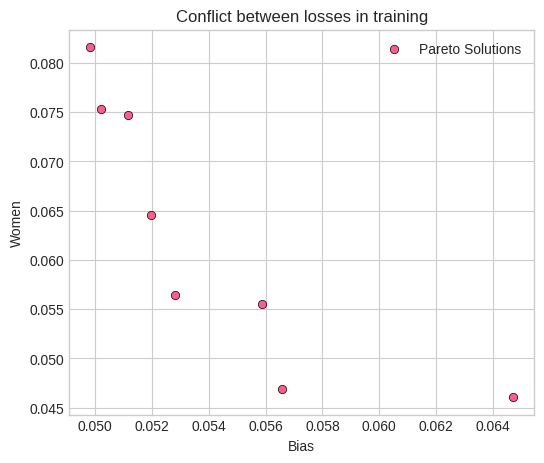

In [ ]:
title="Conflict between losses in training to detect bias"
plot_pareto_2d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name=model_name,
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [ ]:
title="Conflict between losses in training to detect bias"
plot_pareto_2d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

### Random Weights

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name=model_name, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
15:56:45 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
15:56:45 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
15:56:45 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.50s/it]
15:57:02 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


...

Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]
16:11:32 | DEBUG | ml_moo.moo.random_weights | 48th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:11:51 | DEBUG | ml_moo.moo.random_weights | 49th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:12:10 | DEBUG | ml_moo.moo.random_weights | 50th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from ml_moo.analysis.moo_analyzer import Analyzer

16:12:10 | WARNING | ml_moo | [Methods have different numbers of solutions: {8, 50}


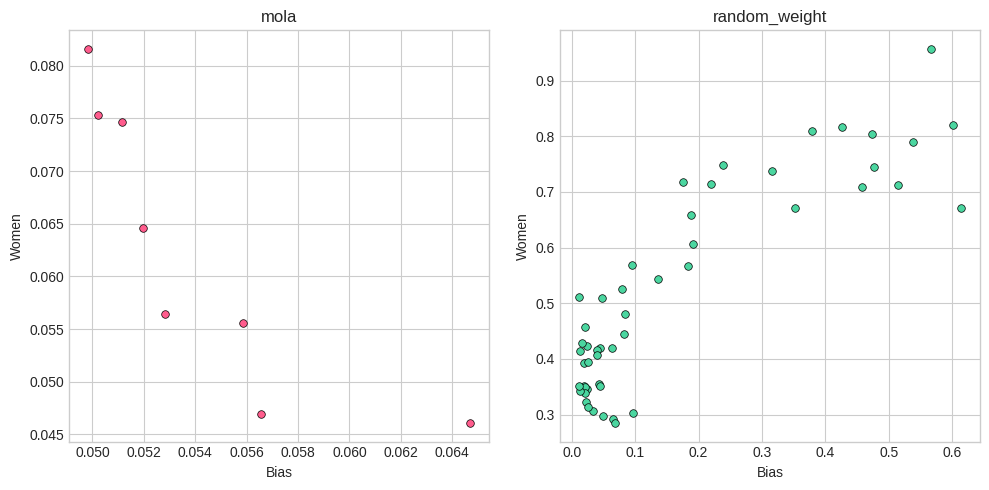

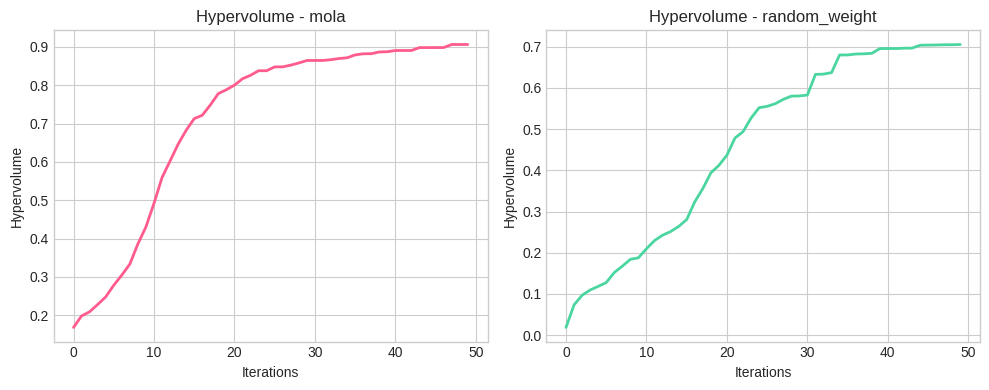

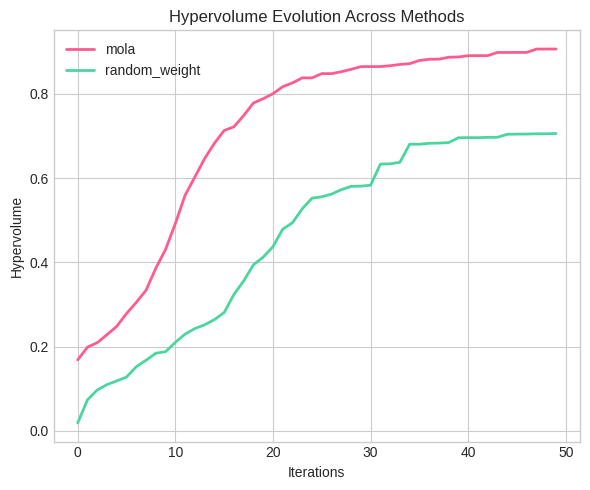

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = task_names
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [ ]:
from ml_moo.analysis.visualization import plot_pareto_2d_set_limit

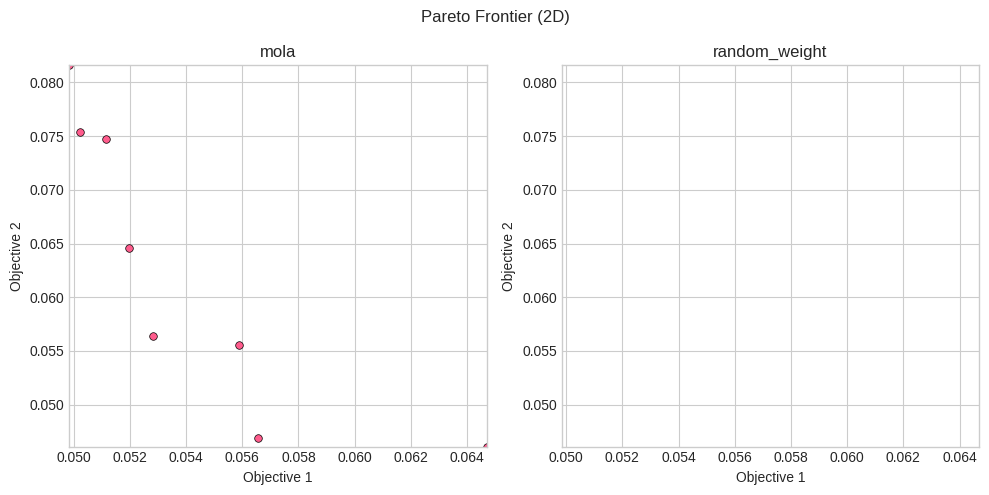

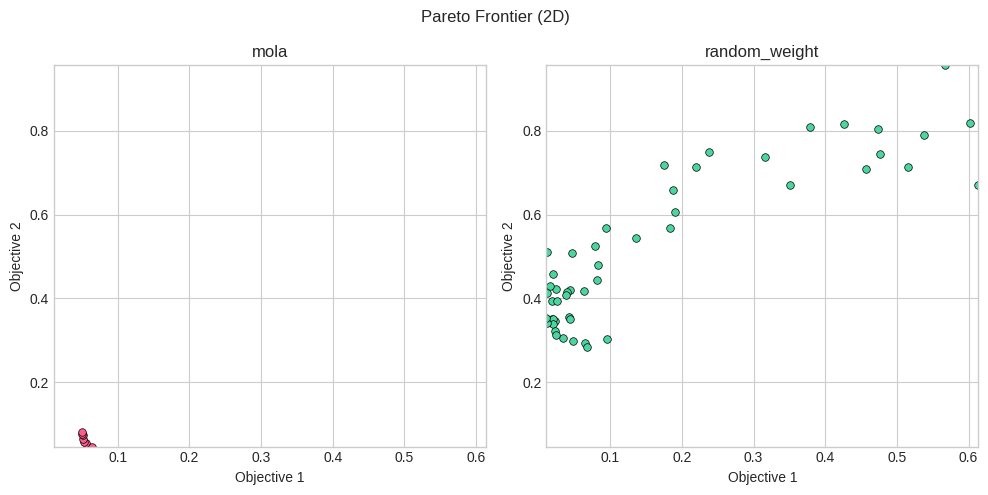

: 

In [ ]:
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 